In [1]:
!python --version

Python 3.14.2


The system cannot find the path specified.


In [2]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# Lightly adapted from https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb

# ___Automatically generating object masks with SAM___
-----------------

Since SAM 2 can efficiently process prompts, masks for the entire image can be generated by sampling a large number of prompts over an image.

The class `SAM2AutomaticMaskGenerator` implements this capability. It works by sampling single-point input prompts in a grid over the image, from each of which SAM can predict multiple masks. Then, masks are filtered for quality and deduplicated using non-maximal suppression. Additional options allow for further improvement of mask quality and quantity, such as running prediction on multiple crops of the image or postprocessing masks to remove small disconnected regions and holes.

In [3]:
import os
from PIL import Image

import numpy as np
np.random.seed(2025 - 11 - 25)
import torch
import matplotlib.pyplot as plt
import cv2

from build_sam import build_sam21_hiera_l
from automatic_mask_generator import SAM2AutomaticMaskGenerator

In [3]:
# select the device for computation
# if torch.cuda.is_available():
#     DEVICE = torch.device("cuda")
# else:
#     DEVICE = torch.device("cpu")
# print(f"using device: {DEVICE}")
# 
# if DEVICE.type == "cuda":
#     # use bfloat16 for the entire notebook
#     torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
#     # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
#     if torch.cuda.get_device_properties(0).major >= 8:
#         torch.backends.cuda.matmul.allow_tf32 = True
#         torch.backends.cudnn.allow_tf32 = True

In [4]:
def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

## Example image

In [5]:
image = np.array(Image.open(r"../images/cars.jpg").convert("RGB"))
image.shape

(1500, 2250, 3)

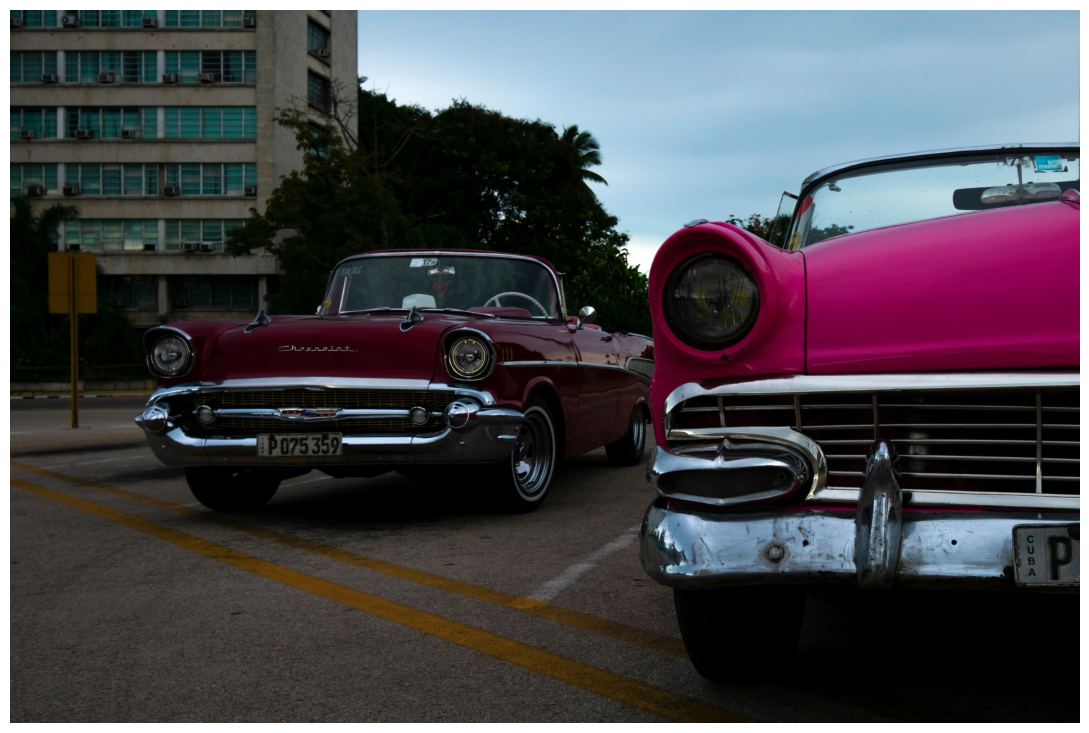

In [6]:
plt.figure(figsize=(11, 7.5))
plt.imshow(image)
plt.axis('off')
plt.tight_layout()
plt.show()

## Automatic mask generation

To run automatic mask generation, provide a version of SAM 2 to the `SAM2AutomaticMaskGenerator` class. Set the path below to the SAM 2 checkpoint.

In [7]:
sam2 = build_sam21_hiera_l(checkpoint_path=r"../../bin/sam2.1_hiera_large.pt", device="cpu", apply_post_processing=False)
mask_generator = SAM2AutomaticMaskGenerator(sam2)

To generate masks, just run `generate` on an image.

In [8]:
masks = mask_generator.generate(image)

Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. These keys are:
* `segmentation` : the mask
* `area` : the area of the mask in pixels
* `bbox` : the boundary box of the mask in XYWH format
* `predicted_iou` : the model's own prediction for the quality of the mask
* `point_coords` : the sampled input point that generated this mask
* `stability_score` : an additional measure of mask quality
* `crop_box` : the crop of the image used to generate this mask in XYWH format

In [10]:
print(len(masks))
print(masks[0].keys())

54
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


Show all the masks overlayed on the image.

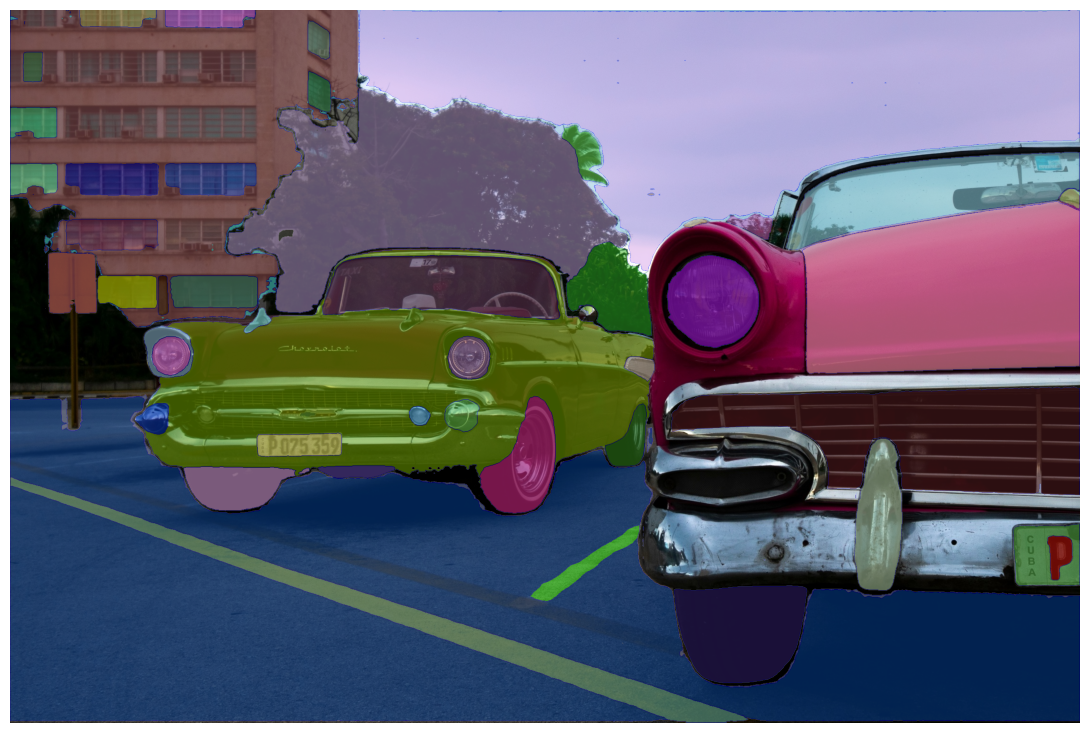

In [13]:
plt.figure(figsize=(11, 7.5))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.tight_layout()
plt.show() 

## Automatic mask generation options

There are several tunable parameters in automatic mask generation that control how densely points are sampled and what the thresholds are for removing low quality or duplicate masks. Additionally, generation can be automatically run on crops of the image to get improved performance on smaller objects, and post-processing can remove stray pixels and holes. Here is an example configuration that samples more masks:

In [16]:
mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=64,
    points_per_batch=128,
    pred_iou_thresh=0.7,
    stability_score_thresh=0.92,
    stability_score_offset=0.7,
    # crop_n_layers=1,
    box_nms_thresh=0.7,
    # crop_n_points_downscale_factor=2,
    min_mask_region_area=25.0,
    # use_m2m=True,
)

In [17]:
masks2 = mask_generator_2.generate(image)

In [18]:
len(masks2)

187

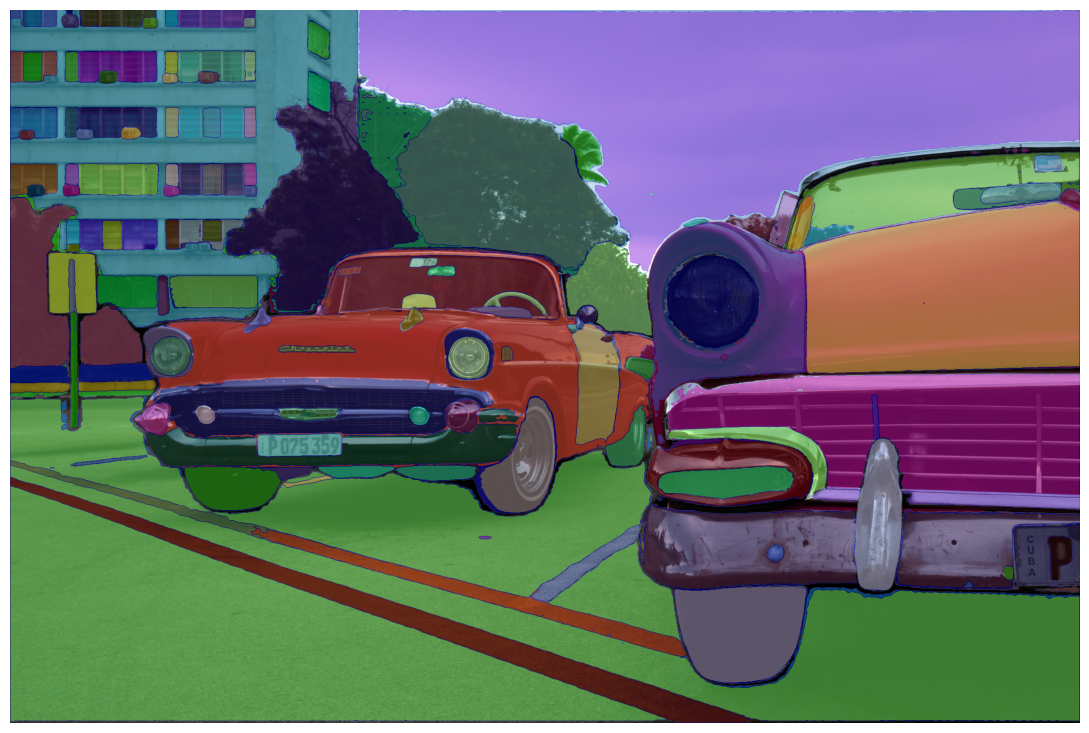

In [20]:
plt.figure(figsize=(11, 7.5))
plt.imshow(image)
show_anns(masks2)
plt.axis('off')
plt.tight_layout()
plt.show() 